# CNN Models

This notebook builds CNN models to classify brain MRI slices as non_demented (CDR = 0) or alzheimer (CDR > 0), using 198 patients from the OASIS-1 cross-sectional dataset (age ≥ 60).

**Structure:**
1. Simple CNN from scratch → establishes that the dataset is too small for training from scratch
2. Transfer learning with EfficientNetB0 → leverages pretrained features to overcome the data limitation

All evaluation is at **patient level**: each patient's 10 slice predictions are averaged (soft voting) before computing metrics.

---
## **1. Config**

In [ ]:
# ============================================================
# Imports
# ============================================================

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# ============================================================
# Mount Drive
# ============================================================

drive.mount('/content/drive') #mount Google Drive to read images and csvs from there

Mounted at /content/drive


In [ ]:
# ============================================================
# Reproducibility
# ============================================================

# removes most run-to-run variation
seed = 42
tf.keras.utils.set_random_seed(seed)

In [ ]:
# ============================================================
# Load manifest and create splits
# ============================================================

project_path = '/content/drive/MyDrive/AlzheimersProject'

manifest_df = pd.read_csv(f'{project_path}/oasis2/manifest_combined.csv')

train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df   = manifest_df[manifest_df["split"] == "val"].copy()
test_df  = manifest_df[manifest_df["split"] == "test"].copy()

class_names = (manifest_df[["label_id", "label"]]
               .drop_duplicates().sort_values("label_id")["label"].tolist())
num_classes = len(class_names)

print(f"train {train_df.subject_id.nunique()} | "
      f"val {val_df.subject_id.nunique()} | "
      f"test {test_df.subject_id.nunique()} patients")
print(class_names)

train 222 | val 48 | test 48 patients
['non_demented', 'alzheimer']


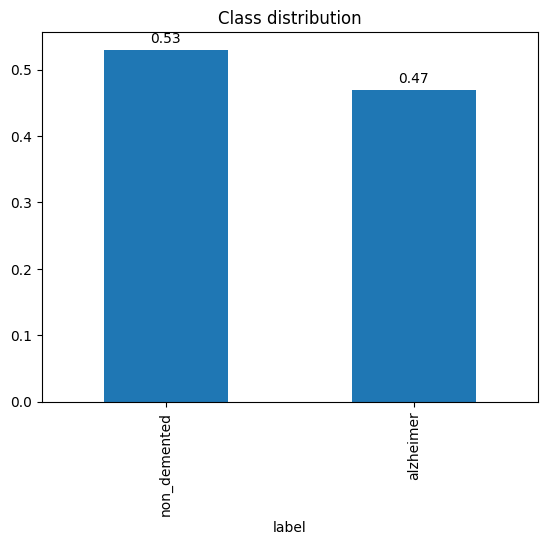

In [ ]:
ax = manifest_df['label'].value_counts(normalize=True).round(2).plot(kind='bar', title='Class distribution')
ax.bar_label(ax.containers[0], padding=3)
plt.show()

In [ ]:
manifest_df.plot(kind='bar', stacked=True, cmap='viridis')
plt.show()

---
## **2. Majority Baseline**

In [ ]:
# ============================================================
# Image level Baseline majority
# ============================================================

train_patients = train_df[['subject_id', 'label_id']].drop_duplicates()
val_patients   = val_df[['subject_id', 'label_id']].drop_duplicates()

# Build y_train_img / y_val_img
y_train_pat = train_patients['label_id'].values
y_val_pat   = val_patients['label_id'].values

# X is not used by DummyClassifier but sklearn requires it
X_train_pat = np.zeros((len(y_train_pat), 1))
X_val_pat   = np.zeros((len(y_val_pat), 1))

dummy_majority = DummyClassifier(strategy='most_frequent', random_state=seed)
dummy_majority.fit(X_train_pat, y_train_pat)   # counts labels to find the majority class
y_pred_majority = dummy_majority.predict(X_val_pat)

print(f"Majority-Class Baseline — patient level (n={len(y_val_pat)})")
print(classification_report(y_val_pat, y_pred_majority,
                            target_names=class_names, zero_division=0))

print("Balanced accuracy:", round(balanced_accuracy_score(y_val_pat, y_pred_majority), 3))
print("Majority floor:", round(max((y_val_pat == 0).mean(), (y_val_pat == 1).mean()), 3))

Majority-Class Baseline — patient level (n=48)
              precision    recall  f1-score   support

non_demented       0.54      1.00      0.70        26
   alzheimer       0.00      0.00      0.00        22

    accuracy                           0.54        48
   macro avg       0.27      0.50      0.35        48
weighted avg       0.29      0.54      0.38        48

Balanced accuracy: 0.5
Majority floor: 0.542


---
## **3. CNN from scratch**

In [ ]:
# ============================================================
# Load images and create training and validation set
# ============================================================

img_size = (224, 224)
batch_size = 32


def load_and_preprocess(path, label):
    """Read a PNG, resize to 224x224, scale pixels to 0-1."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1) # grayscale
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


# Training set: shuffle so the model doesn't see the same order each epoch
train_ds = tf.data.Dataset.from_tensor_slices((train_df["image_path"].values, train_df["label_id"].values)) #getting a list of paths and labels
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE) #using function to load and process images, loading multiple images at the same time
train_ds = train_ds.cache() #this cache stores loaded images in RAM so that after the first epoch it reads from memory (speed optimization)
train_ds = train_ds.shuffle(buffer_size=len(train_df), seed=seed) #shuffling train data, it loads the whole dataset and shuffles it using seed so that it can be reproduced again
train_ds = train_ds.batch(batch_size) #uses a batch of images to compute error and update weights
train_ds = train_ds.prefetch(tf.data.AUTOTUNE) #used so that CPU can start loading and preparing the next batch while the GPU is training the current batch

# Validation set: no shuffle, just load and batch
val_ds = tf.data.Dataset.from_tensor_slices((val_df["image_path"].values, val_df["label_id"].values))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache()
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
# ============================================================
# Build simple CNN
# ============================================================

simple_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 1)),

    # Block 1
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'), #layer of 16 filters (each looking into distinct patterns) going through images 3x3 pixels at a time
    # We use ReLU because it introduces non-linearity to break the linear outputs of Conv2D and other layers.
    # Without ReLU, chaining multiple linear layers is mathematically equivalent to a single layer (e.g., 2x * 3x * 5x = 30x).
    # ReLU breaks linearity by zeroing out negative values (indicating an absent pattern, where negative distinction is unnecessary) while passing positive values through as-is (measuring pattern presence).
    layers.MaxPooling2D((2, 2)),
    # Retains only the highest value in each 2x2 window—halving height & width to extract the strongest features and reduce spatial size.

    # Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classification head
    layers.Flatten(), # Flattens spatial feature maps into a 1D feature vector
    layers.Dense(64, activation='relu'), #Serves as the classifier's feature aggregator, interpreting the patterns extracted by the CNN layers. Contains 64 neurons
    layers.Dense(num_classes, activation='softmax'), # Output layer with one neuron per class; Softmax converts outputs into class probability distributions (sum = 1)
])

simple_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,234,754 (12.34 MB)

 Trainable params: 3,234,754 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Train simple CNN
# ============================================================

simple_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - accuracy: 0.5216 - loss: 0.7037 - val_accuracy: 0.5458 - val_loss: 0.6833
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.5748 - loss: 0.6717 - val_accuracy: 0.4958 - val_loss: 0.7886
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6270 - loss: 0.6376 - val_accuracy: 0.5437 - val_loss: 0.7313
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6896 - loss: 0.5865 - val_accuracy: 0.5688 - val_loss: 0.6949
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7410 - loss: 0.5202 - val_accuracy: 0.5875 - val_loss: 0.7537
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8036 - loss: 0.4347 - val_accuracy: 0.5896 - val_loss: 0.7824
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8459 - loss: 0.3583 - val_accuracy: 0.6000 - val_loss: 0.7837
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8887 - loss: 0.2745 - val_accuracy: 0.6250 - v

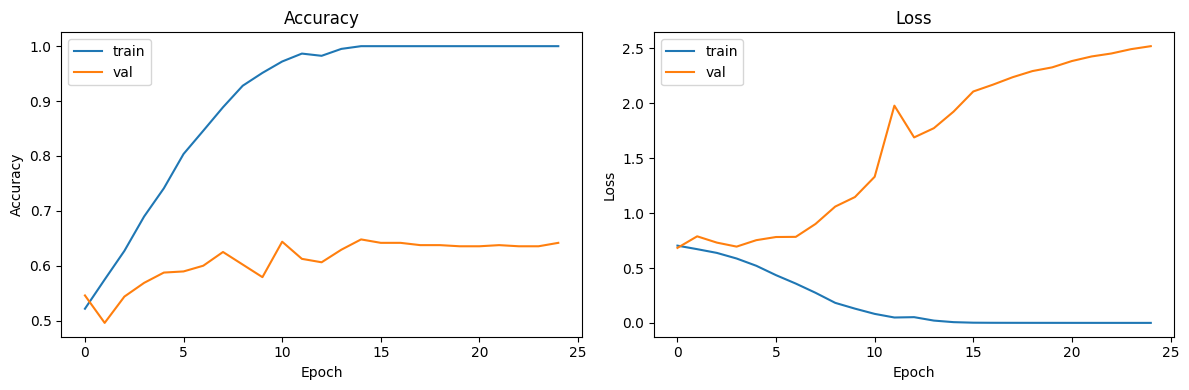

In [ ]:
# ============================================================
# Ploting training curves
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Evaluate simple CNN (patient level with val)
# ============================================================

# Step 1: get probabilities for every slice
y_pred_probs = simple_cnn.predict(val_ds)

# Step 2: attach them to the dataframe
val_eval = val_df.copy()
val_eval["prob_0"] = y_pred_probs[:, 0] #adding column with all the rows with probability of 0
val_eval["prob_1"] = y_pred_probs[:, 1] #adding column with all the rows with probability of 1

# Step 3: average each patient's 10 slice probabilities (soft voting)
patient_pred = (
    val_eval
    .groupby(["subject_id", "label_id"])[["prob_0", "prob_1"]] #grouping by patient and getting the mean of 0 and the mean of 1 of all patient slices
    .mean()
    .reset_index()
)

# Step 4: pick the class with higher average probability
patient_pred["pred"] = patient_pred[["prob_0", "prob_1"]].values.argmax(axis=1) #argmax returns the column index of the max value between prob 0 and 1 of that row

# Step 5: print results
print("Patient-level results:")
print(classification_report(
    patient_pred["label_id"],
    patient_pred["pred"],
    target_names=class_names,
    zero_division=0
))


15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step
Patient-level results:
              precision    recall  f1-score   support

non_demented       0.70      0.81      0.75        26
   alzheimer       0.72      0.59      0.65        22

    accuracy                           0.71        48
   macro avg       0.71      0.70      0.70        48
weighted avg       0.71      0.71      0.70        48



---
## 4. CNN: Augmented training dataset

In [ ]:
# ============================================================
# Augmentation + augmented training dataset
# ============================================================

augmentation_layers = tf.keras.Sequential([
    layers.RandomRotation(0.02, fill_mode='constant', fill_value=0.0),
    layers.RandomTranslation(0.02, 0.02, fill_mode='constant', fill_value=0.0),
    # zoom removed: it directly rescales ventricle-to-brain ratio, which is the discriminative signal
])

def augment_fn(img, label):
    return augmentation_layers(img, training=True), label

train_ds_aug = tf.data.Dataset.from_tensor_slices((train_df["image_path"].values, train_df["label_id"].values))
train_ds_aug = train_ds_aug.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_aug = train_ds_aug.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
# no .cache() here: caching would replay identical "random" augmentations
train_ds_aug = train_ds_aug.shuffle(buffer_size=len(train_df), seed=seed)
train_ds_aug = train_ds_aug.batch(batch_size)
train_ds_aug = train_ds_aug.prefetch(tf.data.AUTOTUNE)

# val_ds stays exactly the same, the data does not get augmented

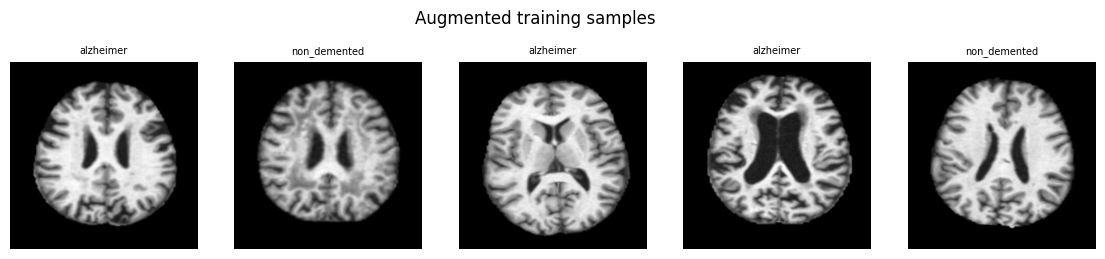

In [ ]:
# ============================================================
# Check augmentation
# ============================================================

for img, lab in train_ds_aug.take(1):
    fig, ax = plt.subplots(1, 5, figsize=(14, 3))
    for k in range(5):
        ax[k].imshow(img[k, :, :, 0], cmap="gray")
        ax[k].set_title(class_names[lab[k]], fontsize=7)
        ax[k].axis("off")
    plt.suptitle("Augmented training samples")
    plt.show()

In [ ]:
# ============================================================
# Build augmented CNN
# ============================================================

# Added two Dropout layers and dropout randomly disables 40% of neurons during each training step. This forces the model to spread its learning across many neurons instead of relying on a few, which reduces memorization (overfitting).
# Dropout automatically turns off during prediction — it only affects training.

augmented_cnn = models.Sequential([ #without dropout
    layers.Input(shape=(224, 224, 1)),

    # Block 1
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classification head — now with dropout
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])

augmented_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,234,754 (12.34 MB)

 Trainable params: 3,234,754 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Train augmented CNN
# ============================================================

augmented_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping watches val_accuracy each epoch. If it doesn't improve for 10 epochs in a row, training stops automatically.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', # not val_loss: it bottoms out at epoch 1 because of overconfidence, which would restore an untrained model
    mode='max',
    patience=10,
    restore_best_weights=True # reverts to the epoch with the best val_accuracy
)

history_aug = augmented_cnn.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=30, # setting epochs=30 as a ceiling — early stopping will cut it short
    callbacks=[early_stop]
)

print("stopped at epoch:", len(history_aug.history['loss']))
print("best val_accuracy:", max(history_aug.history['val_accuracy']))

Path(f'{project_path}/models').mkdir(exist_ok=True)
augmented_cnn.save(f'{project_path}/models/augmented_cnn.keras')
print("model saved")

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5243 - loss: 0.7119 - val_accuracy: 0.5417 - val_loss: 0.6864
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5419 - loss: 0.6881 - val_accuracy: 0.5500 - val_loss: 0.6893
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5649 - loss: 0.6823 - val_accuracy: 0.5208 - val_loss: 0.6788
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5946 - loss: 0.6685 - val_accuracy: 0.5354 - val_loss: 0.6787
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6158 - loss: 0.6466 - val_accuracy: 0.5312 - val_loss: 0.6991
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.6104 - loss: 0.6474 - val_accuracy: 0.5500 - val_loss: 0.7063
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6369 - loss: 0.6346 - val_accuracy: 0.5271 - val_loss: 0.7209
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6419 - loss: 0.6249 - val_accuracy: 0.5458 - v

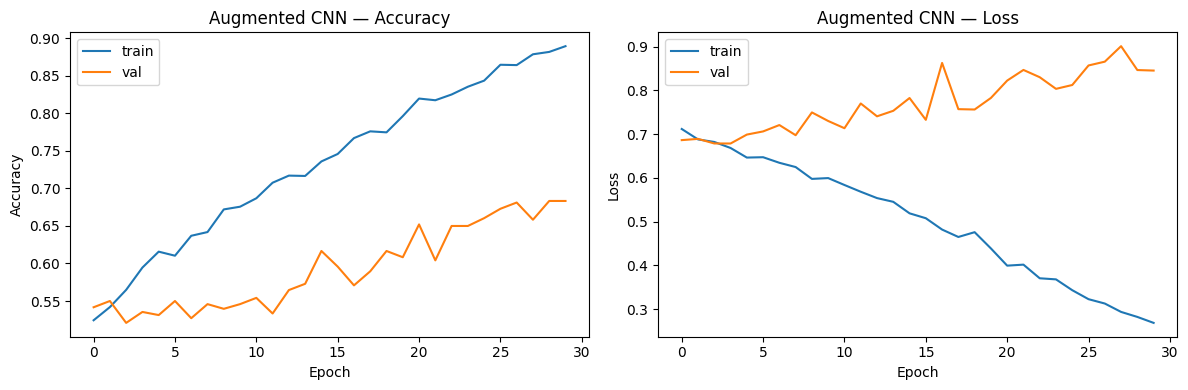

In [ ]:
# ============================================================
# Ploting training curves
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_aug.history['accuracy'], label='train')
plt.plot(history_aug.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Augmented CNN — Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_aug.history['loss'], label='train')
plt.plot(history_aug.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Augmented CNN — Loss')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Evaluate augmented CNN (patient level with val)
# ============================================================

p = augmented_cnn.predict(val_ds)
ev = val_df.copy()
ev["prob_0"], ev["prob_1"] = p[:, 0], p[:, 1]

patient_pred_reg = (ev.groupby(["subject_id", "label_id"])[["prob_0", "prob_1"]]
                      .mean().reset_index())
patient_pred_reg["pred"] = patient_pred_reg[["prob_0", "prob_1"]].values.argmax(axis=1)
patient_pred_reg.to_csv(f'{project_path}/models/patient_pred_reg.csv', index=False)

acc = (patient_pred_reg["label_id"] == patient_pred_reg["pred"]).mean()
ba  = balanced_accuracy_score(patient_pred_reg["label_id"], patient_pred_reg["pred"])
auc = roc_auc_score(patient_pred_reg["label_id"], patient_pred_reg["prob_1"])
print(f"Augmented CNN — acc {acc:.3f} | balanced {ba:.3f} | AUC {auc:.3f}")

print(classification_report(patient_pred_reg["label_id"], patient_pred_reg["pred"],
                            target_names=class_names, zero_division=0))

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 461ms/step
Augmented CNN — acc 0.771 | balanced 0.757 | AUC 0.822
              precision    recall  f1-score   support

non_demented       0.73      0.92      0.81        26
   alzheimer       0.87      0.59      0.70        22

    accuracy                           0.77        48
   macro avg       0.80      0.76      0.76        48
weighted avg       0.79      0.77      0.76        48



In [ ]:
#Saving history_aug
pd.DataFrame(history_aug.history).to_csv(f'{project_path}/models/history_aug.csv', index=False)

In [ ]:
cdr = val_df.drop_duplicates("subject_id")[["subject_id", "cdr"]]
pr = patient_pred_reg.merge(cdr, on="subject_id")

print(f"Specificity (CDR 0, n={(pr.cdr==0).sum()}): {(pr[pr.cdr==0].pred==0).mean():.2f}")
for c in [0.5, 1.0]:
    g = pr[pr.cdr == c]
    if len(g):
        print(f"Recall CDR {c} (n={len(g)}): {(g.pred==1).mean():.2f}")

Specificity (CDR 0, n=26): 0.92
Recall CDR 0.5 (n=16): 0.50
Recall CDR 1.0 (n=5): 0.80


---
## 6. Transfer Learning — EfficientNetB0

In [ ]:
# ============================================================
# Load images as RGB (224×224, 0–255 range)
# ============================================================

def load_and_preprocess_rgb(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) #not divided by 225 as this model already does the normalization
    img = tf.image.grayscale_to_rgb(img)
    return img, label

# Training set
train_ds_rgb = tf.data.Dataset.from_tensor_slices((train_df["image_path"].values, train_df["label_id"].values))
train_ds_rgb = train_ds_rgb.map(load_and_preprocess_rgb, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_rgb = train_ds_rgb.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_rgb = train_ds_rgb.shuffle(buffer_size=len(train_df), seed=seed)
train_ds_rgb = train_ds_rgb.batch(batch_size)
train_ds_rgb = train_ds_rgb.prefetch(tf.data.AUTOTUNE)

# Validation set: no shuffle
val_ds_rgb = tf.data.Dataset.from_tensor_slices((val_df["image_path"].values, val_df["label_id"].values))
val_ds_rgb = val_ds_rgb.map(load_and_preprocess_rgb, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_rgb = val_ds_rgb.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# ============================================================
# Build transfer learning model
# ============================================================

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze ALL layers — we don't want to change the pretrained features yet.
# The model already knows how to detect edges, textures, and shapes.
# We just need to teach it which of those features matter for Alzheimer's.
base_model.trainable = False

# We stack our own classification head on top of the frozen backbone
transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(), # GlobalAveragePooling2D: the backbone outputs a (4, 4, 1280) feature map.
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])

transfer_model.summary()

print(f"trainable: {sum(p.numpy().size for p in transfer_model.trainable_weights):,}")
print(f"frozen:    {sum(p.numpy().size for p in transfer_model.non_trainable_weights):,}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

trainable: 164,226
frozen:    4,049,571


In [ ]:
# ============================================================
# Compile and train
# ============================================================

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=7,
    restore_best_weights=True
)

history_phase1 = transfer_model.fit(
    train_ds_rgb,
    validation_data=val_ds_rgb,
    epochs=20,
    callbacks=[early_stop_phase1]
)

print("stopped at epoch:", len(history_phase1.history['loss']), "of 20")
print("best epoch:", int(np.argmax(history_phase1.history['val_accuracy'])) + 1)
print("best val_accuracy:", round(max(history_phase1.history['val_accuracy']), 3))

augmented_cnn.save(f'{project_path}/models/augmented_cnn.keras')
patient_pred_reg.to_csv(f'{project_path}/models/patient_pred_reg.csv', index=False)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.5644 - loss: 0.6891 - val_accuracy: 0.5875 - val_loss: 0.6546
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.6023 - loss: 0.6647 - val_accuracy: 0.5958 - val_loss: 0.6604
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.6203 - loss: 0.6410 - val_accuracy: 0.5833 - val_loss: 0.6947
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.6311 - loss: 0.6416 - val_accuracy: 0.5896 - val_loss: 0.6699
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.6387 - loss: 0.6275 - val_accuracy: 0.5875 - val_loss: 0.6779
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.6541 - loss: 0.6135 - val_accuracy: 0.5813 - val_loss: 0.6711
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.6554 - loss: 0.6131 - val_accuracy: 0.5708 - val_loss: 0.6877
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.6518 - loss: 0.6226 - val_accuracy: 0.6125 - v

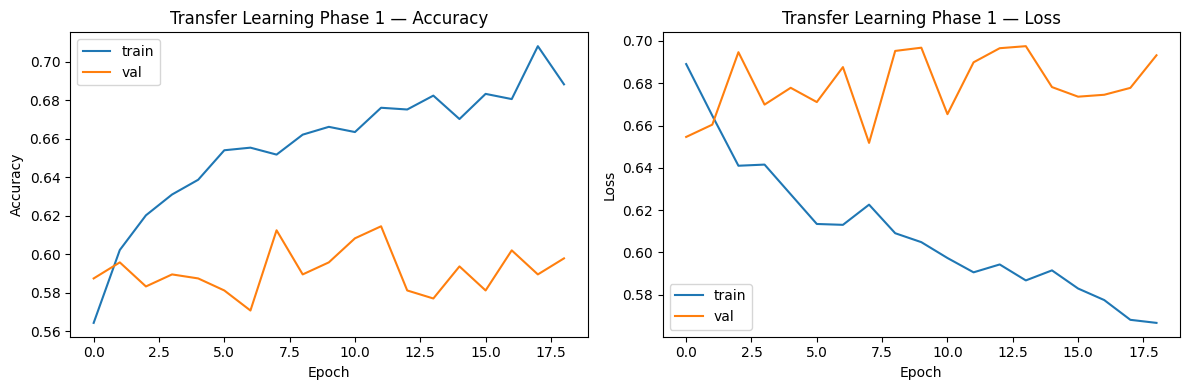

In [ ]:
# ============================================================
# Ploting training curves
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='train')
plt.plot(history_phase1.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Transfer Learning Phase 1 — Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'], label='train')
plt.plot(history_phase1.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Transfer Learning Phase 1 — Loss')

plt.tight_layout()
plt.show()

In [ ]:
train_ds_rgb = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label_id"].values))
train_ds_rgb = train_ds_rgb.map(load_and_preprocess_rgb, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_rgb = train_ds_rgb.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_rgb = train_ds_rgb.shuffle(buffer_size=500, seed=seed)
train_ds_rgb = train_ds_rgb.batch(batch_size)
train_ds_rgb = train_ds_rgb.prefetch(tf.data.AUTOTUNE)

In [ ]:
# ============================================================
# Phase 2 — Fine-tuning
# ============================================================
# Phase 1 only trained the head on frozen ImageNet features, and it
# plateaued at 0.615. Those features detect edges and textures from
# everyday photos, not brain atrophy. Unfreezing the top blocks lets the
# backbone adapt its features to MRI.

base_model.trainable = True

# Only the last 20 layers train; earlier layers keep generic low-level
# features (edges, gradients) that transfer fine.
for layer in base_model.layers[:-20]:
    layer.trainable = False

# BatchNormalization always stays frozen. With a batch of 32, recomputing
# its statistics is too noisy and destabilizes fine-tuning — this is the
# single most common cause of transfer learning failing.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"{trainable_layers} of {len(base_model.layers)} backbone layers trainable")
print(f"trainable params: {sum(p.numpy().size for p in transfer_model.trainable_weights):,}")

15 of 238 backbone layers trainable
trainable params: 1,506,994


In [ ]:
# ============================================================
# Compile and train phase 2
# ============================================================
# lr = 1e-5 is 100x smaller than phase 1. We are nudging pretrained
# weights, not retraining them: a high lr would destroy them in the
# first few steps.

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=8,
    restore_best_weights=True
)

history_phase2 = transfer_model.fit(
    train_ds_rgb,
    validation_data=val_ds_rgb,
    epochs=20,
    callbacks=[early_stop_phase2]
)

print("stopped at epoch:", len(history_phase2.history['loss']), "of 20")
print("best epoch:", int(np.argmax(history_phase2.history['val_accuracy'])) + 1)
print("best val_accuracy:", round(max(history_phase2.history['val_accuracy']), 3))

augmented_cnn.save(f'{project_path}/models/augmented_cnn.keras')
patient_pred_reg.to_csv(f'{project_path}/models/patient_pred_reg.csv', index=False)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.6685 - loss: 0.6032 - val_accuracy: 0.5979 - val_loss: 0.7273
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.6405 - loss: 0.6289 - val_accuracy: 0.6000 - val_loss: 0.7232
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.6459 - loss: 0.6225 - val_accuracy: 0.5979 - val_loss: 0.7155
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.6514 - loss: 0.6170 - val_accuracy: 0.5958 - val_loss: 0.7171
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.6550 - loss: 0.6154 - val_accuracy: 0.5979 - val_loss: 0.7101
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.6581 - loss: 0.6116 - val_accuracy: 0.5958 - val_loss: 0.7076
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6563 - loss: 0.6121 - val_accuracy: 0.6042 - val_loss: 0.7030
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.6626 - loss: 0.6089 - val_accuracy: 0.6104 - v

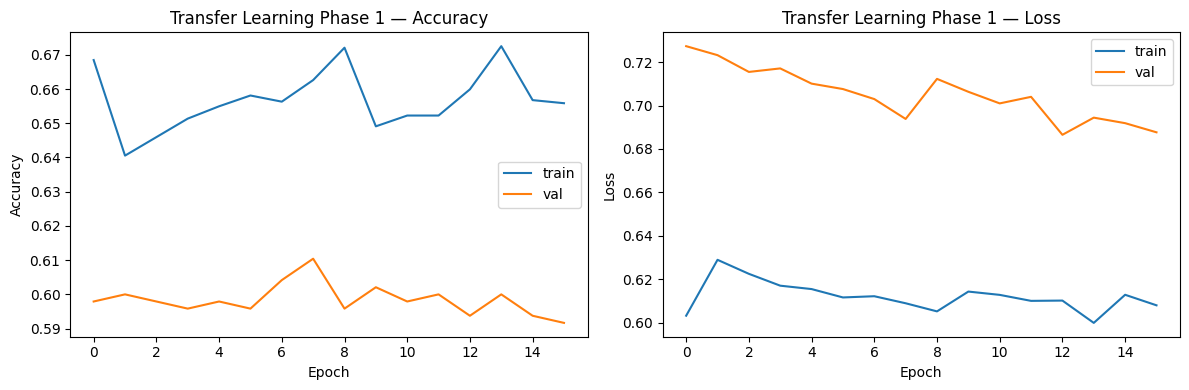

In [ ]:
# ============================================================
# Ploting training curves
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_phase2.history['accuracy'], label='train')
plt.plot(history_phase2.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Transfer Learning Phase 1 — Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_phase2.history['loss'], label='train')
plt.plot(history_phase2.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Transfer Learning Phase 1 — Loss')

plt.tight_layout()
plt.show()

In [ ]:
p2 = transfer_model.predict(val_ds_rgb)
print("std of prob_1:", round(float(p2[:, 1].std()), 4))

val_eval_p2 = val_df.copy()
val_eval_p2["prob_0"] = p2[:, 0]
val_eval_p2["prob_1"] = p2[:, 1]

patient_p2 = (val_eval_p2
              .groupby(["subject_id", "label_id"])[["prob_0", "prob_1"]]
              .mean().reset_index())
patient_p2["pred"] = patient_p2[["prob_0", "prob_1"]].values.argmax(axis=1)

print(f"Phase 2 — Patient-level results ({len(patient_p2)} patients):")
print(classification_report(patient_p2["label_id"], patient_p2["pred"],
                            target_names=class_names, zero_division=0))
print("AUC:", round(roc_auc_score(patient_p2["label_id"], patient_p2["prob_1"]), 3))
print("Balanced acc:", round(balanced_accuracy_score(patient_p2["label_id"],
                                                     patient_p2["pred"]), 3))

15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step
std of prob_1: 0.185
Phase 2 — Patient-level results (48 patients):
              precision    recall  f1-score   support

non_demented       0.60      0.96      0.74        26
   alzheimer       0.83      0.23      0.36        22

    accuracy                           0.62        48
   macro avg       0.71      0.59      0.55        48
weighted avg       0.70      0.62      0.56        48

AUC: 0.708
Balanced acc: 0.594


In [ ]:
from pathlib import Path
Path(f'{project_path}/models').mkdir(exist_ok=True)

transfer_model.save(f'{project_path}/models/transfer_p2.keras')
patient_p2.to_csv(f'{project_path}/models/patient_p2.csv', index=False)
print("guardado")

guardado


---
## **Test models**

In [ ]:
def evaluate_test(model, ds, name):
    p = model.predict(ds, verbose=0)
    ev = test_df.copy()
    ev["prob_0"], ev["prob_1"] = p[:, 0], p[:, 1]
    pt = (ev.groupby(["subject_id", "label_id"])[["prob_0", "prob_1"]]
            .mean().reset_index())
    pt["pred"] = pt[["prob_0", "prob_1"]].values.argmax(axis=1)
    pt.to_csv(f'{project_path}/models/test_{name}.csv', index=False)

    acc = (pt["label_id"] == pt["pred"]).mean()
    ba  = balanced_accuracy_score(pt["label_id"], pt["pred"])
    auc = roc_auc_score(pt["label_id"], pt["prob_1"])
    print(f"{name:<16} acc {acc:.3f} | balanced {ba:.3f} | AUC {auc:.3f}")
    return pt

# test_ds for 1-channel models, test_ds_rgb for the transfer model
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_id"].values))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_rgb = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_id"].values))
test_ds_rgb = test_ds_rgb.map(load_and_preprocess_rgb, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_rgb = test_ds_rgb.batch(batch_size).prefetch(tf.data.AUTOTUNE)

pt_aug = evaluate_test(augmented_cnn,  test_ds,     "augmented_cnn")
pt_tp2 = evaluate_test(transfer_model, test_ds_rgb, "transfer_p2")

augmented_cnn    acc 0.771 | balanced 0.768 | AUC 0.798
transfer_p2      acc 0.583 | balanced 0.570 | AUC 0.671


In [ ]:
tp = test_df[["subject_id", "label_id"]].drop_duplicates()
majority = train_df[["subject_id","label_id"]].drop_duplicates().label_id.mode()[0]
pred = np.full(len(tp), majority)
print(f"{'Dummy':<16} acc {(tp.label_id == pred).mean():.3f} | balanced 0.500 | AUC 0.500")

Dummy            acc 0.521 | balanced 0.500 | AUC 0.500


In [ ]:
cdr = test_df.drop_duplicates("subject_id")[["subject_id", "cdr"]]
pr = pt_aug.merge(cdr, on="subject_id")
print(f"Specificity (CDR 0, n={(pr.cdr==0).sum()}): {(pr[pr.cdr==0].pred==0).mean():.2f}")
for c in [0.5, 1.0]:
    g = pr[pr.cdr == c]
    if len(g):
        print(f"Recall CDR {c} (n={len(g)}): {(g.pred==1).mean():.2f}")

Specificity (CDR 0, n=25): 0.84
Recall CDR 0.5 (n=18): 0.67
Recall CDR 1.0 (n=5): 0.80


In [ ]:
# ============================================================
# Image loading functions (same as the original notebook)
# ============================================================

img_size = (224, 224)
batch_size = 32

def load_and_preprocess(path, label):
    """Read a PNG, resize to 224x224, scale pixels to 0-1."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)  # grayscale
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def load_and_preprocess_rgb(path, label):
    """Same, but converts to RGB and does NOT normalize (EfficientNet does it internally)."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    img = tf.image.grayscale_to_rgb(img)
    return img, label

In [ ]:
# ============================================================
# Test datasets
# ============================================================

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_id"].values))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_rgb = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_id"].values))
test_ds_rgb = test_ds_rgb.map(load_and_preprocess_rgb, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_rgb = test_ds_rgb.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# ============================================================
# Load saved models (.keras)
# ============================================================

augmented_cnn = tf.keras.models.load_model(f'{project_path}/models/augmented_cnn.keras')
transfer_model = tf.keras.models.load_model(f'{project_path}/models/transfer_p2.keras')

print("Models loaded successfully")

Models loaded successfully


In [ ]:
# ============================================================
# Evaluate_test with classification_report and confusion_matrix
# ============================================================

def evaluate_test_full(model, ds, name):
    # Step 1: get slice-level probabilities
    p = model.predict(ds, verbose=0)
    ev = test_df.copy()
    ev["prob_0"], ev["prob_1"] = p[:, 0], p[:, 1]

    # Step 2: soft voting - average the 10 slices per patient
    pt = (ev.groupby(["subject_id", "label_id"])[["prob_0", "prob_1"]]
            .mean().reset_index())
    pt["pred"] = pt[["prob_0", "prob_1"]].values.argmax(axis=1)

    # Step 3: accuracy, balanced accuracy, AUC
    acc = (pt["label_id"] == pt["pred"]).mean()
    ba  = balanced_accuracy_score(pt["label_id"], pt["pred"])
    auc = roc_auc_score(pt["label_id"], pt["prob_1"])

    # Step 4: classification report as a dict (for the summary table later)
    report = classification_report(
        pt["label_id"], pt["pred"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    # Step 5: NEW - confusion matrix
    # labels=[0, 1] forces the order: row/col 0 = non_demented, row/col 1 = alzheimer
    cm = confusion_matrix(pt["label_id"], pt["pred"], labels=[0, 1])

    # Step 6: print everything to check visually
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"acc {acc:.3f} | balanced {ba:.3f} | AUC {auc:.3f}")
    print(classification_report(pt["label_id"], pt["pred"],
                                target_names=class_names, zero_division=0))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(f"                 pred_{class_names[0]:<12} pred_{class_names[1]}")
    print(f"actual_{class_names[0]:<12} {cm[0,0]:>10}   {cm[0,1]:>10}")
    print(f"actual_{class_names[1]:<12} {cm[1,0]:>10}   {cm[1,1]:>10}")

    return {"name": name, "accuracy": acc, "balanced_acc": ba, "auc": auc,
            "report": report, "confusion_matrix": cm, "predictions": pt}

In [ ]:
# ============================================================
# Run test set evaluation
# ============================================================

results = {}

# Baseline (majority class dummy)
majority_class = train_df[["subject_id","label_id"]].drop_duplicates().label_id.mode()[0]
tp_dummy = test_df[["subject_id", "label_id"]].drop_duplicates()
pred_dummy = np.full(len(tp_dummy), majority_class)

report_dummy = classification_report(
    tp_dummy["label_id"], pred_dummy,
    target_names=class_names, output_dict=True, zero_division=0
)
cm_dummy = confusion_matrix(tp_dummy["label_id"], pred_dummy, labels=[0, 1])

print("Baseline (Dummy)")
print(classification_report(tp_dummy["label_id"], pred_dummy,
                            target_names=class_names, zero_division=0))
print("Confusion matrix (rows=actual, cols=predicted):")
print(f"                 pred_{class_names[0]:<12} pred_{class_names[1]}")
print(f"actual_{class_names[0]:<12} {cm_dummy[0,0]:>10}   {cm_dummy[0,1]:>10}")
print(f"actual_{class_names[1]:<12} {cm_dummy[1,0]:>10}   {cm_dummy[1,1]:>10}")

results["baseline"] = {
    "name": "Baseline",
    "accuracy": (tp_dummy["label_id"] == pred_dummy).mean(),
    "report": report_dummy,
    "confusion_matrix": cm_dummy
}

# Augmented CNN
results["augmented_cnn"] = evaluate_test_full(augmented_cnn, test_ds, "Augmented CNN")

# Transfer learning
results["transfer"] = evaluate_test_full(transfer_model, test_ds_rgb, "Transfer Learning")

Baseline (Dummy)
              precision    recall  f1-score   support

non_demented       0.52      1.00      0.68        25
   alzheimer       0.00      0.00      0.00        23

    accuracy                           0.52        48
   macro avg       0.26      0.50      0.34        48
weighted avg       0.27      0.52      0.36        48

Confusion matrix (rows=actual, cols=predicted):
                 pred_non_demented pred_alzheimer
actual_non_demented         25            0
actual_alzheimer            23            0

Augmented CNN
acc 0.771 | balanced 0.768 | AUC 0.798
              precision    recall  f1-score   support

non_demented       0.75      0.84      0.79        25
   alzheimer       0.80      0.70      0.74        23

    accuracy                           0.77        48
   macro avg       0.78      0.77      0.77        48
weighted avg       0.77      0.77      0.77        48

Confusion matrix (rows=actual, cols=predicted):
                 pred_non_demented pred_a

In [ ]:
# ============================================================
# Final summary table
# ============================================================

summary_rows = []
for key, res in results.items():
    rep = res["report"]
    summary_rows.append({
        "Model": res["name"],
        "Accuracy": round(res["accuracy"], 2),
        "Precision (macro)": round(rep["macro avg"]["precision"], 2),
        "Recall (macro)": round(rep["macro avg"]["recall"], 2),
        "F1 (macro)": round(rep["macro avg"]["f1-score"], 2),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

In [ ]:
def plot_confusion_matrix(cm, class_names, title):
    """Plot a single confusion matrix as a seaborn heatmap."""
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,       # write the numbers inside each cell
        fmt="d",          # format numbers as integers (not decimals)
        cmap="Blues",     # color scale
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True         # show the color scale bar on the side
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()   # avoids labels getting cut off
    plt.show()

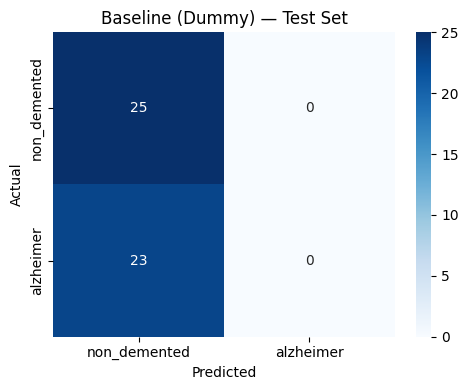

In [ ]:
plot_confusion_matrix(
    results["baseline"]["confusion_matrix"],
    class_names,
    "Baseline (Dummy) — Test Set"
)

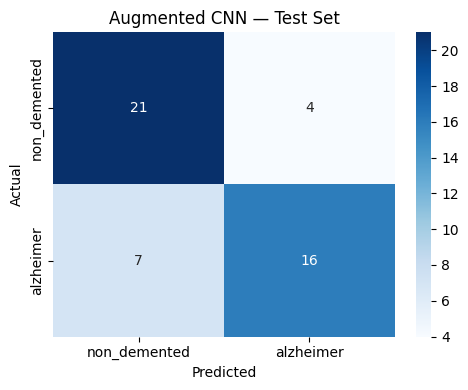

In [ ]:
plot_confusion_matrix(
    results["augmented_cnn"]["confusion_matrix"],
    class_names,
    "Augmented CNN — Test Set"
)


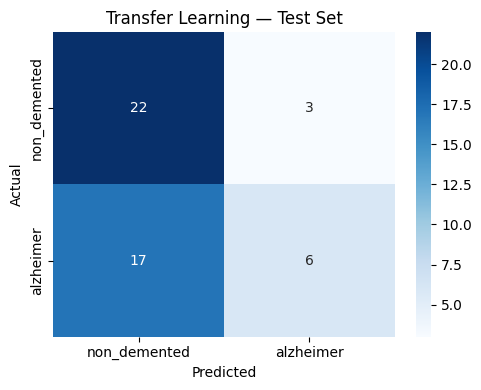

In [ ]:
plot_confusion_matrix(
    results["transfer"]["confusion_matrix"],
    class_names,
    "Transfer Learning — Test Set"
)

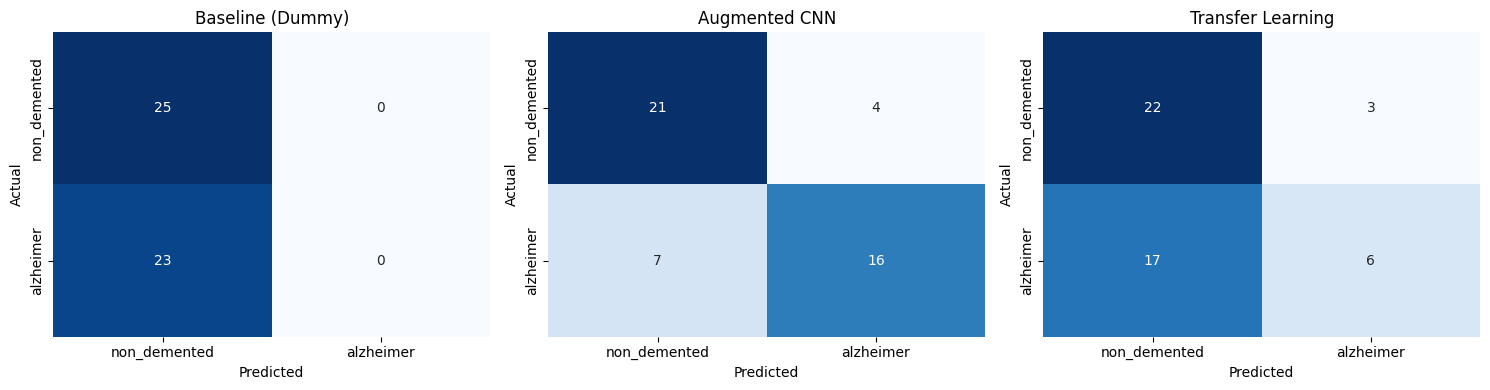

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_to_plot = [
    ("baseline", "Baseline (Dummy)"),
    ("augmented_cnn", "Augmented CNN"),
    ("transfer", "Transfer Learning"),
]

for ax, (key, title) in zip(axes, models_to_plot):
    cm = results[key]["confusion_matrix"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,     # no need to repeat the color bar 3 times
        ax=ax           # tells seaborn which subplot to draw into
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.show()